In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob 

In [56]:
paths = glob.glob("**/*full_results.csv", recursive=True)
dataframes = [pd.read_csv(file)[['language', 'subject', 'llm', 'fertility_subject_wise', 'fertility_language_wise']] for file in paths]
df = pd.concat(dataframes)

df.head()

,language,subject,llm,fertility_subject_wise,fertility_language_wise
0,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
1,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
2,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
3,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
4,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844


In [57]:
df[df['language']=='amh']

,language,subject,llm,fertility_subject_wise,fertility_language_wise
0,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
1,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
2,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
3,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
4,amh,elementary_mathematics,Google/gemini-15-Pro-002,3.946738,4.632844
...,...,...,...,...,...
495,amh,high_school_microeconomics,microsoft/phi-4,11.396918,10.745161
496,amh,high_school_microeconomics,microsoft/phi-4,11.396918,10.745161
497,amh,high_school_microeconomics,microsoft/phi-4,11.396918,10.745161
498,amh,high_school_microeconomics,microsoft/phi-4,11.396918,10.745161


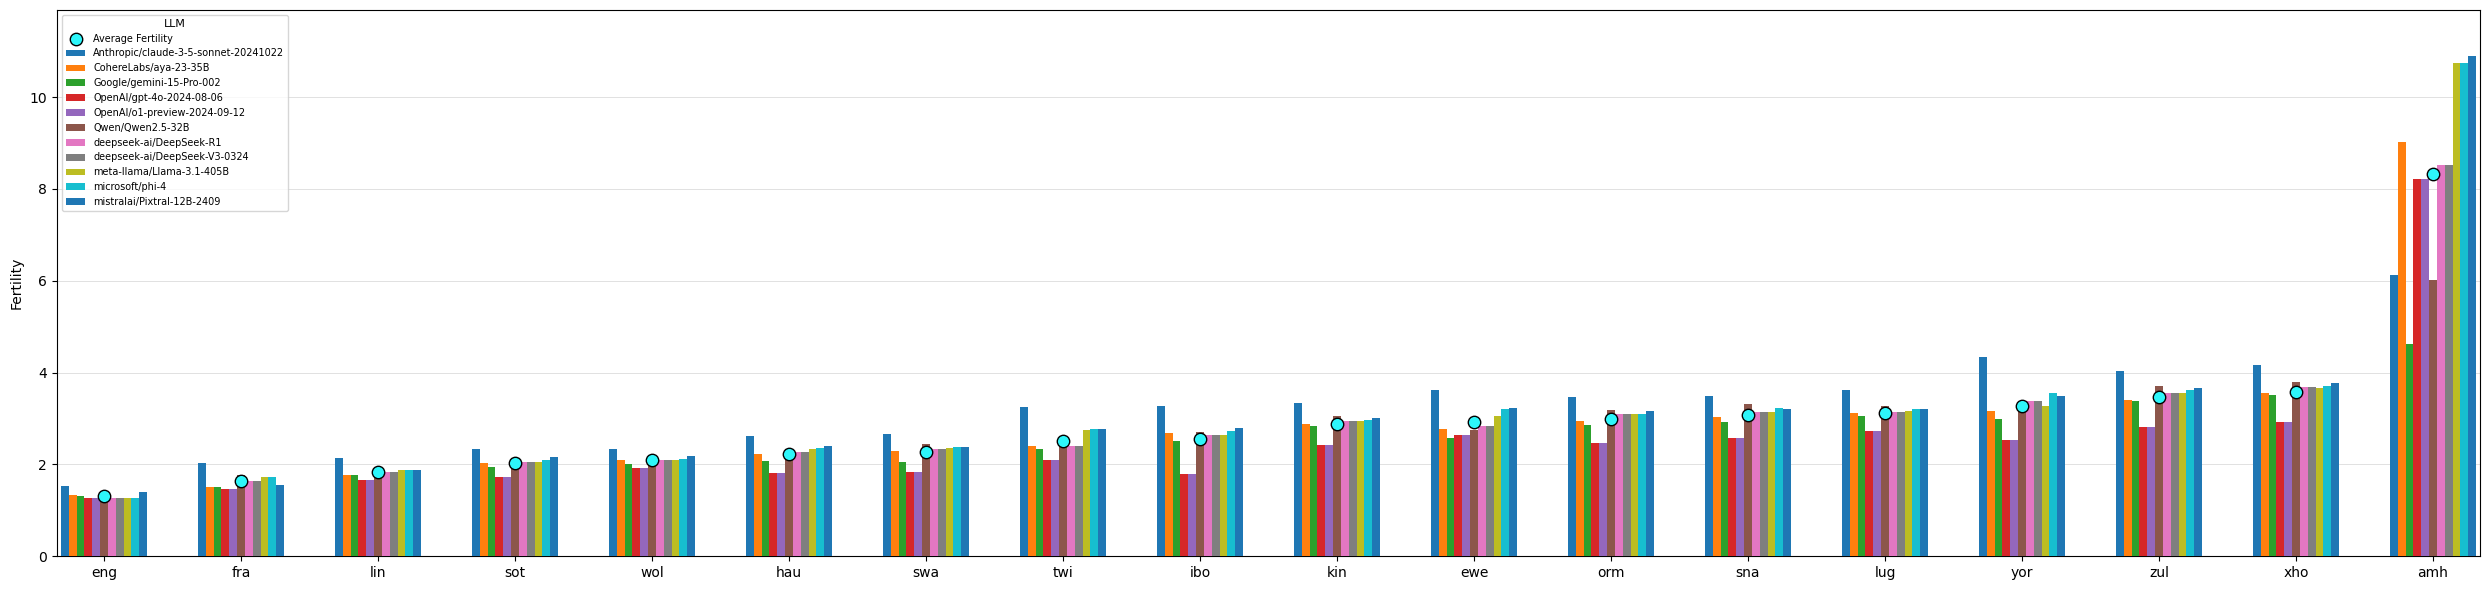

In [58]:
################################################################################################
# Fertility by Language and LLM
################################################################################################
# grouped_fertilities = df.groupby(['language', 'llm'], as_index=False)['fertility_language_wise'].mean()
grouped_fertilities = (
    df.groupby(['language', 'llm'], as_index=False)['fertility_language_wise']
      .first()
)

pivot_df = grouped_fertilities.pivot(index='language', columns='llm', values='fertility_language_wise')

# Get average fertility
pivot_df['fertility'] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values(by='fertility', ascending=True)
fertility = pivot_df['fertility']
pivot_df = pivot_df.drop(columns=['fertility']) # Now drop so it's not extra bar

fig, ax = plt.subplots(figsize=(25, 6))
bar_width = 2
languages = pivot_df.index
llms = pivot_df.columns

x = np.arange(len(languages)) * (1 + 17 * bar_width)  # Add space between languages
for i, tokenizer in enumerate(llms):
    ax.bar(x + i * bar_width, pivot_df[tokenizer], bar_width, label=tokenizer, zorder=3)

# Points for the fertility
ax.scatter(
    x + bar_width * (len(llms) - 1) / 2, 
    fertility, 
    color='#2df6fa', 
    label='Average Fertility', 
    zorder=5, 
    s=80, 
    edgecolor='black'
)

ax.set_xticks(x + bar_width * (len(llms) - 1) / 2)
ax.set_xticklabels(languages) # rotation=45
ax.set_ylabel('Fertility')
ax.set_xlim(x[0] - bar_width, x[-1] + bar_width * len(llms))
ax.set_ylim(0, pivot_df.values.max()+1)
# ax.set_title('Average Fertility by Language and LLM')
ax.legend(title='LLM', fontsize=7, title_fontsize=8)
plt.grid(color='#d4d4d4', linewidth=0.5, axis='y')
plt.tight_layout()
plt.show()